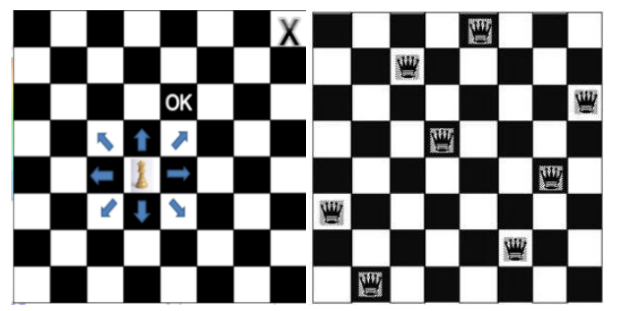

In [ ]:
import numpy as np

# Define parameters
board_size = 8
pop_size = 50
mutation_rate = 0.1
max_iter = 1000
convergence_threshold = 10

In [ ]:
# Generate initial population
def generate_population(pop_size, board_size):
    return np.array([np.random.permutation(board_size) for _ in range(pop_size)])

# # Fitness function
# def fitness(chromosome):
#   ### write your code here
#     return 1 / (attacks)  # Higher fitness for fewer attacks  :)

def fitness(chromosome):
    board_size = len(chromosome)
    horizontal_collisions = sum([chromosome.tolist().count(queen)-1 for queen in chromosome])/2
    diagonal_collisions = 0

    n = len(chromosome)
    left_diagonal = [0] * (2*n-1)
    right_diagonal = [0] * (2*n-1)
    for i in range(n):
        left_diagonal[i + chromosome[i]] += 1
        right_diagonal[n - i + chromosome[i] - 1] += 1

    diagonal_collisions = 0
    for i in range(2*n-1):
        if left_diagonal[i] > 1:
            diagonal_collisions += left_diagonal[i]-1
        if right_diagonal[i] > 1:
            diagonal_collisions += right_diagonal[i]-1

    # The total number of attacking queens is the sum of horizontal and diagonal collisions
    total_collisions = horizontal_collisions + diagonal_collisions
    max_attacks = board_size * (board_size - 1) // 2  # Max possible number of attacks
    return max_attacks - total_collisions  # Higher fitness for fewer attacks

In [ ]:
# Selection using tournament selection
def tournament_selection(population, fitness_scores, tournament_size=3):
    selected_indices = []
    population_size = len(population)

    for _ in range(population_size):
        # Randomly select `tournament_size` individuals from the population
        tournament = np.random.choice(population_size, tournament_size, replace=False)

        # Get the index of the individual with the highest fitness in the tournament
        best_index = tournament[np.argmax(fitness_scores[tournament])]

        # Append the selected individual (best of the tournament) to selected_indices
        selected_indices.append(best_index)

    return population[selected_indices]

# Crossover
def crossover(parent1, parent2):
    # Choose a random crossover point (any point in the chromosome except the last one)
    crossover_point = np.random.randint(1, len(parent1))

    # Create children by swapping segments between the parents at the crossover point
    child1 = np.concatenate((parent1[:crossover_point], parent2[crossover_point:]))
    child2 = np.concatenate((parent2[:crossover_point], parent1[crossover_point:]))

    return child1, child2

In [ ]:
# Mutation
def mutate(chromosome, mutation_rate=0.05):
    # With a probability of mutation_rate, we mutate the chromosome
    if np.random.rand() < mutation_rate:
        # Select two random positions (genes) to swap
        i, j = np.random.choice(len(chromosome), 2, replace=False)

        # Swap the positions of the two queens (genes)
        chromosome[i], chromosome[j] = chromosome[j], chromosome[i]

    return chromosome

# Main genetic algorithm loop
population = generate_population(pop_size, board_size)
best_fitness = -np.inf
consecutive_no_improvement = 0


In [ ]:
def genetic_algorithm(board_size=8, pop_size=50, generations=1000, mutation_rate=0.1, convergence_threshold=10):
    population = generate_population(pop_size, board_size)
    fitness_scores = np.array([fitness(chromosome) for chromosome in population])

    best_fitness = np.max(fitness_scores)
    best_index = np.argmax(fitness_scores)
    best_solution = population[best_index]
    consecutive_no_improvement = 0

    for generation in range(generations):
        # Evaluate fitness
        fitness_scores = np.array([fitness(chromosome) for chromosome in population])

        # Track the best solution
        current_best_fitness = np.max(fitness_scores)
        current_best_index = np.argmax(fitness_scores)

        if current_best_fitness > best_fitness:
            best_fitness = current_best_fitness
            best_solution = population[current_best_index]
            consecutive_no_improvement = 0
        else:
            consecutive_no_improvement += 1

        # Check for convergence
        if consecutive_no_improvement >= convergence_threshold:
            print(f"Converged after {generation} generations.")
            break

        # Selection
        selected_population = tournament_selection(population, fitness_scores)

        # Crossover and mutation
        new_population = []
        for i in range(0, pop_size, 2):
            parent1 = selected_population[i]
            parent2 = selected_population[(i + 1) % pop_size]
            child1, child2 = crossover(parent1, parent2)
            new_population.append(mutate(child1, mutation_rate))
            new_population.append(mutate(child2, mutation_rate))

        population = np.array(new_population)

    # Print the results
    print("\033[1;32mBest solution:\033[0m")
    print("\033[1;36m", best_solution, "\033[0m")
    print("\033[1;32mFitness:\033[0m", "\033[1;36m", best_fitness, "\033[0m")

    return best_solution, best_fitness



In [ ]:
# Run the genetic algorithm
genetic_algorithm(board_size, pop_size, max_iter, mutation_rate, convergence_threshold)

Converged after 9 generations.
Best solution:
 [5 7 1 3 0 2 4 6] 
Fitness:  27.0 


(array([5, 7, 1, 3, 0, 2, 4, 6]), 27.0)